In [2]:
import polars as pl

pdb_af3 = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet")

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch
from scipy import stats


def plot_rmsd_bars_all(
    pdb_df: pl.DataFrame, inf_type: str, title: str | None = None
) -> plt.Figure:
    n = pdb_df.height

    replic_means = (
        pdb_df.filter(pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            # pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )
    post_means = (
        pdb_df.filter(~pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            # pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )

    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD"]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    # pre-training boxplots (blue)
    ax.boxplot(
        replic_means,
        positions=x - width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )

    # post-training boxplots (orange)
    ax.boxplot(
        post_means,
        positions=x + width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    # ax.set_yticks(np.arange(0, 21, 1))

    # y-axis label
    ax.set_ylabel(f"RMSD between true and crystal structure (Å)")

    if title:
        ax.set_title(title)

    pre_patch = Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label=f"Pre-training (n={replic_means.shape[0]})",
    )
    post_patch = Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label=f"Post-training (n={post_means.shape[0]})",
    )
    ax.legend(handles=[pre_patch, post_patch], loc="upper left")

    plt.tight_layout()
    return fig


def plot_rmsd_bars(
    pdb_df: pl.DataFrame,
    inf_type: str,
    rmsd_type: str,
    title: str | None = None,
) -> plt.Figure:
    """
    Plot a single RMSD type (peptide/mhc/tcr/cdr) for pre- vs post-training as side-by-side boxplots.

    Parameters
    ----------
    pdb_df : pl.DataFrame
        Must include a boolean 'replication' column and RMSD columns like:
        '<rmsd_type>_rmsd_<inf_type>_4', e.g., 'peptide_rmsd_af3_4'
    inf_type : str
        Inference type token in the column names (e.g., 'af3', 'pred', etc.)
    rmsd_type : {'peptide','mhc','tcr','cdr'}
        Which RMSD family to plot.
    title : str | None
        Optional figure title.
    """
    rmsd_type_norm = rmsd_type.lower()
    valid = {
        "peptide": "Peptide RMSD",
        "mhc": "MHC RMSD",
        "tcr": "TCR RMSD",
        "cdr": "CDR RMSD",
    }
    if rmsd_type_norm not in valid:
        raise ValueError(f"rmsd_type must be one of {list(valid)}")

    col = f"{rmsd_type_norm}_rmsd_{inf_type}_4"
    if col not in pdb_df.columns:
        raise KeyError(f"Expected column '{col}' not found in DataFrame.")

    # Split pre/post
    pre_vals = (
        pdb_df.filter(pl.col("replication")).select(pl.col(col)).to_numpy().squeeze()
    )
    post_vals = (
        pdb_df.filter(~pl.col("replication")).select(pl.col(col)).to_numpy().squeeze()
    )

    # Ensure 1D arrays
    pre_vals = np.atleast_1d(pre_vals)
    post_vals = np.atleast_1d(post_vals)

    fig, ax = plt.subplots(figsize=(5, 8))
    width = 0.35

    # Single position (x=0), two boxes offset left/right
    ax.boxplot(
        [pre_vals],
        positions=[-width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )
    ax.boxplot(
        [post_vals],
        positions=[+width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    # X tick centered at 0 with chosen label
    ax.set_xticks([0])
    ax.set_xticklabels([valid[rmsd_type_norm]], rotation=0, ha="center")

    # ax.set_ylabel("RMSD between true and crystal structure (Å)")
    if title:
        ax.set_title(title)

    pre_patch = Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label=f"Pre-training (n={pre_vals.shape[0]})",
    )
    post_patch = Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label=f"Post-training (n={post_vals.shape[0]})",
    )
    # ax.legend(handles=[pre_patch, post_patch], loc="upper left")

    plt.tight_layout()
    return fig

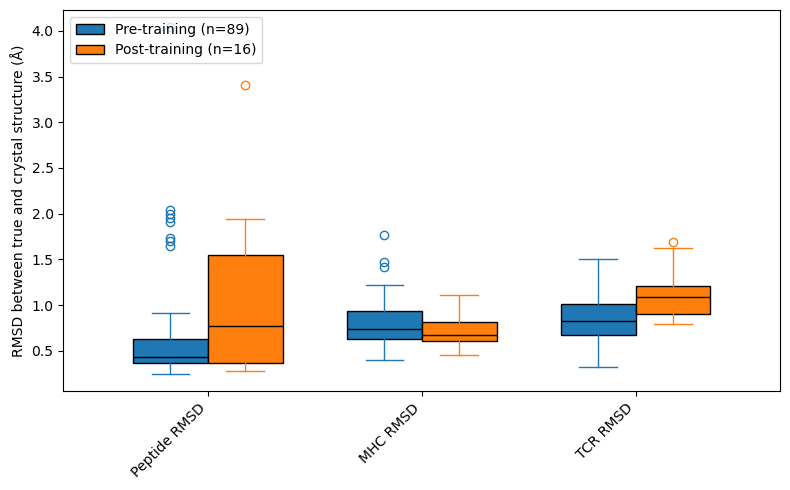

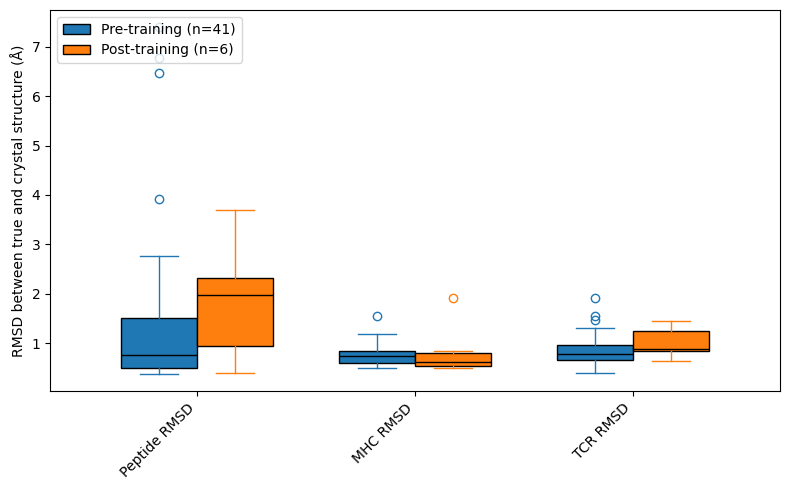

In [36]:
fig = plot_rmsd_bars_all(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3")
fig = plot_rmsd_bars_all(pdb_af3.filter(pl.col("mhc_class") == "II"), "af3")

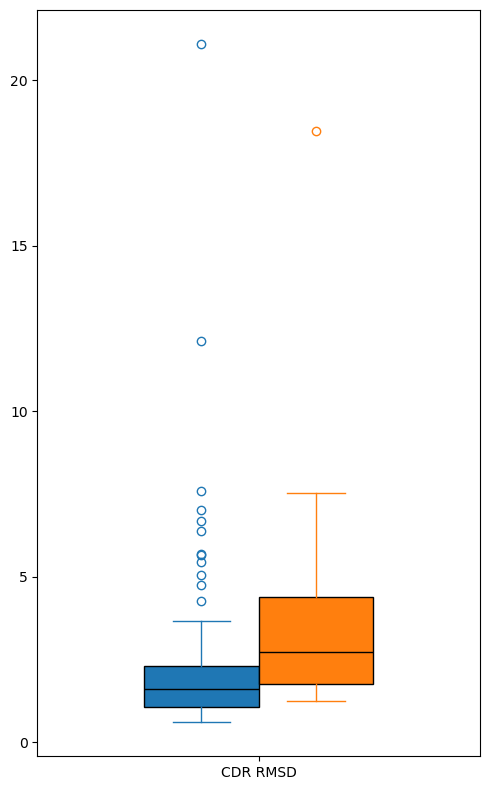

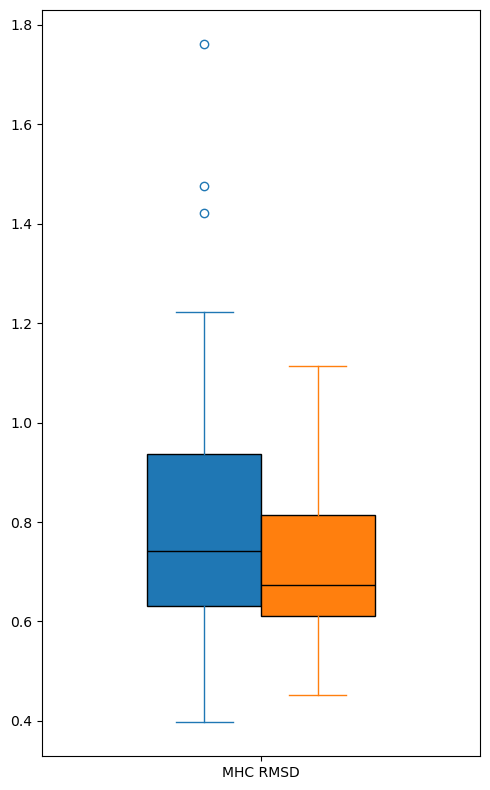

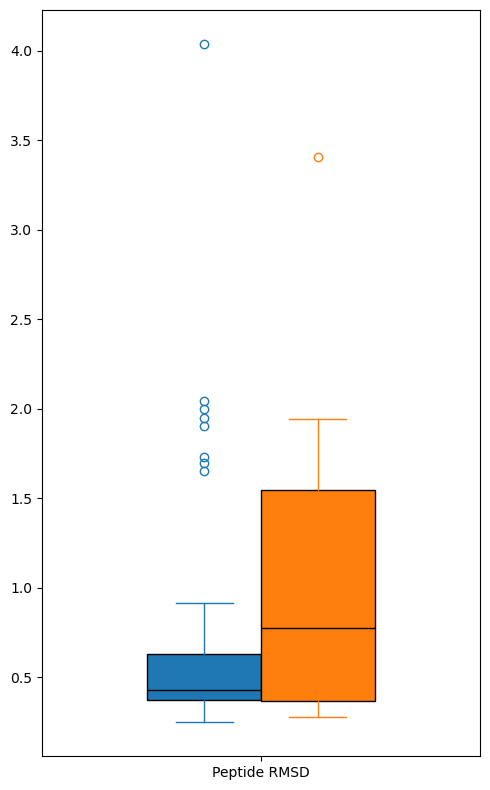

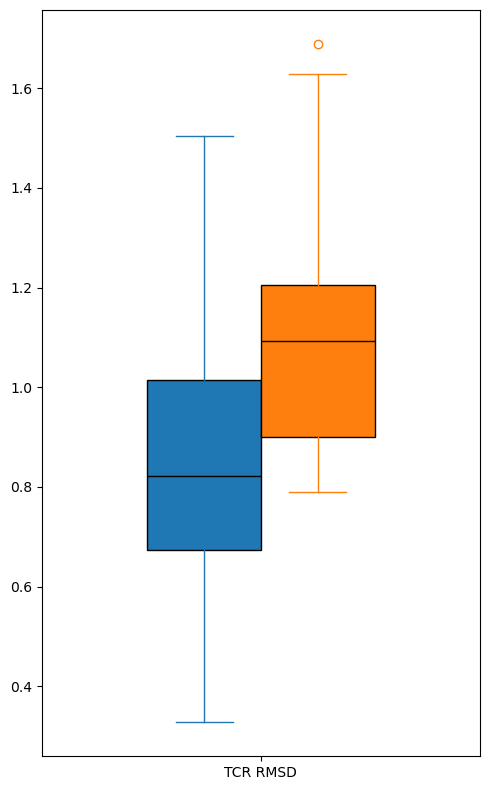

In [31]:
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "cdr")
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "mhc")
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "peptide")
fig = plot_rmsd_bars(pdb_af3.filter(pl.col("mhc_class") == "I"), "af3", "tcr")